In [1]:
import time
import psutil
import torch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TEST_TEXT = """
Machine learning techniques are increasingly used for phishing detection.
Transformers provide strong contextual understanding.
"""

# -------------------------
# Load Models
# -------------------------

bert_model_name = "bert-base-uncased"
gpt_model_name = "gpt2"

print("Loading Models...")

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(
    bert_model_name
).to(DEVICE)

gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_model_name)

if gpt_tokenizer.pad_token is None:
    gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

gpt_model = AutoModelForCausalLM.from_pretrained(
    gpt_model_name
).to(DEVICE)

# -------------------------
# Benchmark Function
# -------------------------

def benchmark(model, tokenizer, text, model_type):

    process = psutil.Process()

    memory_before = process.memory_info().rss / 1024**2

    tokens = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    tokens = {k:v.to(DEVICE) for k,v in tokens.items()}

    start = time.time()

    with torch.no_grad():

        if model_type == "BERT":
            output = model(**tokens)

        else:
            output = model.generate(
                tokens["input_ids"],
                max_new_tokens=50
            )

    end = time.time()

    memory_after = process.memory_info().rss / 1024**2

    total_tokens = tokens["input_ids"].shape[1]

    return {
        "Latency(sec)": round(end-start,4),
        "Tokens": total_tokens,
        "Memory(MB)": round(
            memory_after-memory_before,
            2
        ),
        "Tokens/sec":
            round(total_tokens/(end-start),2)
    }

# -------------------------
# Run Benchmarks
# -------------------------

bert_results = benchmark(
    bert_model,
    bert_tokenizer,
    TEST_TEXT,
    "BERT"
)

gpt_results = benchmark(
    gpt_model,
    gpt_tokenizer,
    TEST_TEXT,
    "GPT"
)

# -------------------------
# Print Results
# -------------------------

print("\n===== Benchmark Results =====")

print("\nBERT")
for k,v in bert_results.items():
    print(k,":",v)

print("\nGPT")
for k,v in gpt_results.items():
    print(k,":",v)

print("\nModel Info")

print("BERT Context Window: 512")
print("GPT2 Context Window: 1024")

print("Device:", DEVICE)

Loading Models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



===== Benchmark Results =====

BERT
Latency(sec) : 0.2349
Tokens : 20
Memory(MB) : 330.93
Tokens/sec : 85.15

GPT
Latency(sec) : 2.0761
Tokens : 21
Memory(MB) : 471.97
Tokens/sec : 10.11

Model Info
BERT Context Window: 512
GPT2 Context Window: 1024
Device: cpu


Loading Models...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



===== Benchmark Results =====

BERT: {'Latency': 0.4877, 'Tokens': 20, 'Memory': 322.5, 'Tokens_per_sec': 41.01}
GPT: {'Latency': 4.0793, 'Tokens': 21, 'Memory': 468.71, 'Tokens_per_sec': 5.15}

Device: cpu


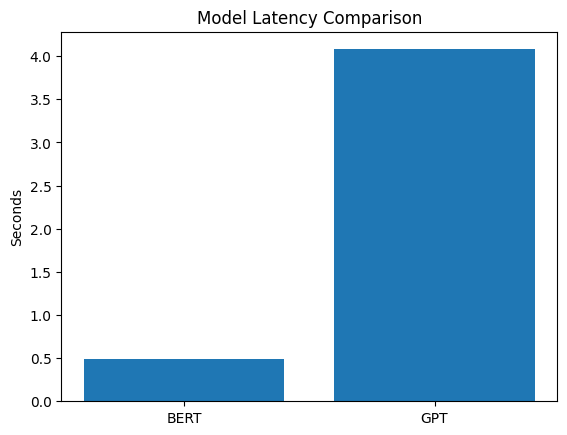

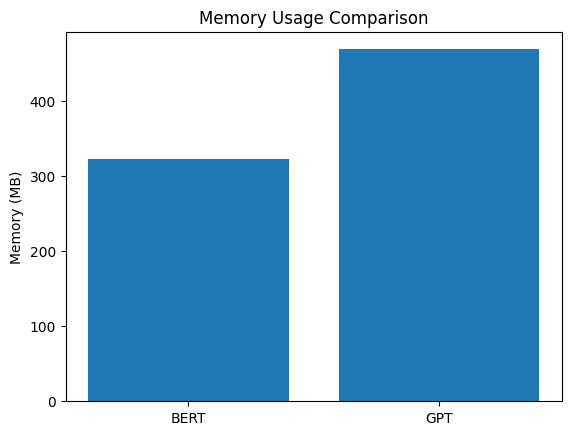

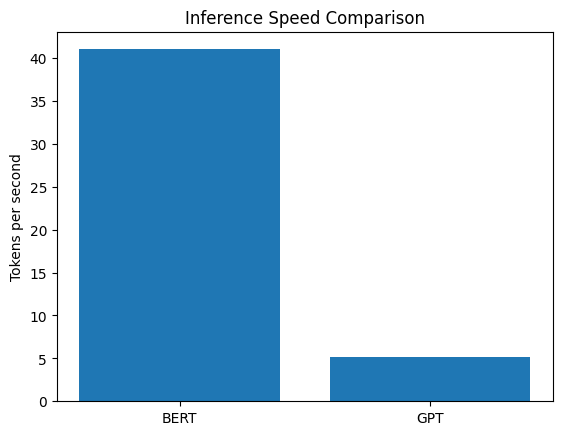

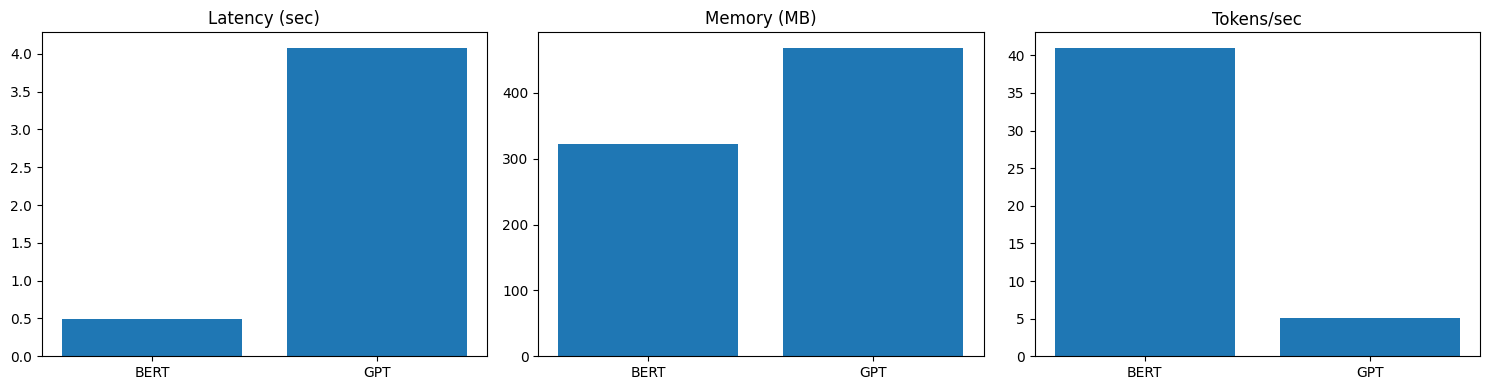

In [2]:
import time
import psutil
import torch
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM
)

# -------------------------
# Setup
# -------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TEST_TEXT = """
Machine learning techniques are increasingly used for phishing detection.
Transformers provide strong contextual understanding.
"""

# -------------------------
# Load Models
# -------------------------

bert_model_name = "bert-base-uncased"
gpt_model_name = "gpt2"

print("Loading Models...")

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert_model = AutoModel.from_pretrained(bert_model_name).to(DEVICE)

gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_model_name)

if gpt_tokenizer.pad_token is None:
    gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

gpt_model = AutoModelForCausalLM.from_pretrained(gpt_model_name).to(DEVICE)

# -------------------------
# Benchmark Function
# -------------------------

def benchmark(model, tokenizer, text, model_type):

    process = psutil.Process()

    memory_before = process.memory_info().rss / 1024**2

    tokens = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    tokens = {k: v.to(DEVICE) for k, v in tokens.items()}

    start = time.time()

    with torch.no_grad():
        if model_type == "BERT":
            model(**tokens)
        else:
            model.generate(
                tokens["input_ids"],
                max_new_tokens=50
            )

    end = time.time()

    memory_after = process.memory_info().rss / 1024**2

    total_tokens = tokens["input_ids"].shape[1]

    return {
        "Latency": round(end - start, 4),
        "Tokens": total_tokens,
        "Memory": round(memory_after - memory_before, 2),
        "Tokens_per_sec": round(total_tokens / (end - start), 2)
    }

# -------------------------
# Run Benchmarks
# -------------------------

bert_results = benchmark(bert_model, bert_tokenizer, TEST_TEXT, "BERT")
gpt_results = benchmark(gpt_model, gpt_tokenizer, TEST_TEXT, "GPT")

# -------------------------
# Print Results
# -------------------------

print("\n===== Benchmark Results =====\n")

print("BERT:", bert_results)
print("GPT:", gpt_results)

print("\nDevice:", DEVICE)

# -------------------------
# DATA FOR PLOTTING
# -------------------------

models = ["BERT", "GPT"]

latency = [bert_results["Latency"], gpt_results["Latency"]]
memory = [bert_results["Memory"], gpt_results["Memory"]]
speed = [bert_results["Tokens_per_sec"], gpt_results["Tokens_per_sec"]]

# -------------------------
# MATPLOTLIB GRAPHS
# -------------------------

# 1. Latency
plt.figure()
plt.bar(models, latency)
plt.title("Model Latency Comparison")
plt.ylabel("Seconds")
plt.show()

# 2. Memory
plt.figure()
plt.bar(models, memory)
plt.title("Memory Usage Comparison")
plt.ylabel("Memory (MB)")
plt.show()

# 3. Speed
plt.figure()
plt.bar(models, speed)
plt.title("Inference Speed Comparison")
plt.ylabel("Tokens per second")
plt.show()

# -------------------------
# COMBINED DASHBOARD VIEW
# -------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(models, latency)
axs[0].set_title("Latency (sec)")

axs[1].bar(models, memory)
axs[1].set_title("Memory (MB)")

axs[2].bar(models, speed)
axs[2].set_title("Tokens/sec")

plt.tight_layout()
plt.show()